In [20]:
import numpy as np
import matplotlib.pyplot as plt
 
from sklearn.svm import SVR, SVC
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor
from sklearn.ensemble import ExtraTreesRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.model_selection import cross_val_score, KFold
from sklearn.model_selection import LeaveOneOut, cross_val_score
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.inspection import partial_dependence, PartialDependenceDisplay

from sklearn.metrics import r2_score
from scipy.stats import norm, rankdata
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
from scipy.stats.qmc import LatinHypercube
 
from skopt.sampler import Lhs
from skopt.space import Space
 
import shap
import torch
import torch.nn as nn
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings('ignore', category=ConvergenceWarning)

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


# Helper Functions

In [21]:
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma
 
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei
 
def format_query(point, decimals=6):
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])
 
def thompson_sample(gp, candidates, n_samples=10, subsample=500):
    idx = np.random.choice(len(candidates), size=min(subsample, len(candidates)), replace=False)
    sub = candidates[idx]
    samples = gp.sample_y(sub, n_samples=n_samples, random_state=42)
    best_sub_idx = np.argmax(samples.mean(axis=1))
    return idx[best_sub_idx]
 
# MC dropout prediction
# model must be in train() mode so dropout stays active during prediction
def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()

# Function 1 - week 8

Function 1 - Week 8
Largest gap: -19.6 to -39.6
Floor set at: -29.6
Strongest detection: -3.606063e-03 at [0.65011406 0.68152635]
  log reading: -2.4
Log reading range: -29.6 to -2.4

All points (sorted by detection strength):
  [0.65011406 0.68152635] --> output: -3.606e-03 --> log reading: -2.4
  [0.694651 0.629916] --> output: -1.607e-03 --> log reading: -2.8
  [0.461537 0.459084] --> output: -1.688e-05 --> log reading: -4.8
  [0.504751 0.602966] --> output: 1.949e-12 --> log reading: -11.7
  [0.73102363 0.73299988] --> output: 7.711e-16 --> log reading: -15.1
  [0.618043 0.460066] --> output: 2.603e-20 --> log reading: -19.6
  [0.31269116 0.07872278] --> output: -2.089e-91 --> log reading: -29.6
  [0.57432921 0.8798981 ] --> output: 1.033e-46 --> log reading: -29.6
  [0.84035342 0.26473161] --> output: 3.342e-124 --> log reading: -29.6
  [0.41043714 0.1475543 ] --> output: -2.159e-54 --> log reading: -29.6
  [0.08250725 0.40348751] --> output: 3.607e-81 --> log reading: -29.6
  [0.

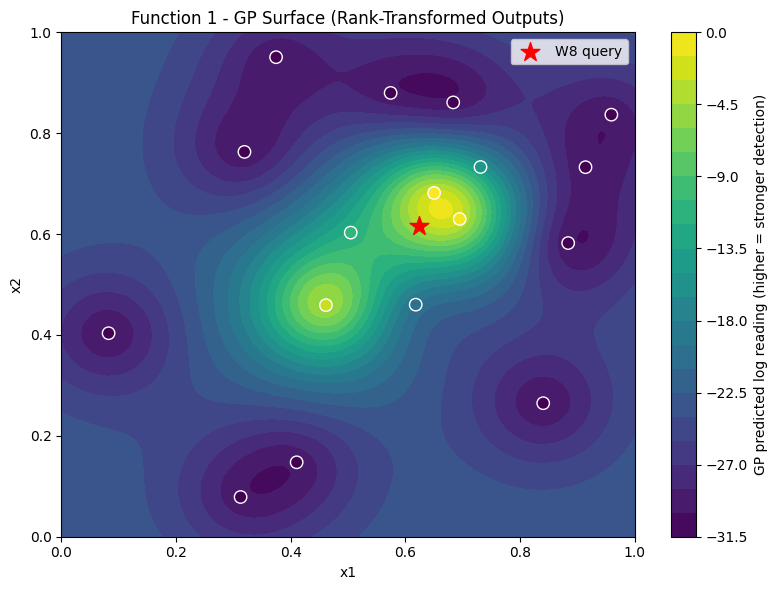

In [22]:
# =============================================================================
# FUNCTION 1 - Radiation Detection (2D)
# changes: 
#     - kappa from 4.0 to 2.0 for less exploration
#     - length_scale = 0.15 -> 0.102 use intra-source point separation to calculate length scales --
#       there were not enough signal points to make variable-length scales
# =============================================================================
 
print("=" * 60)
print("Function 1 - Week 8")
print("=" * 60)
 
inputs  = np.load('../Data/function_1/initial_inputs.npy')
outputs = np.load('../Data/function_1/initial_outputs.npy')
 
prev_queries = np.array([
    [0.959184, 0.836735],  
    [0.374540, 0.950714],  
    [0.694651, 0.629916],  
    [0.461537, 0.459084],  
    [0.618043, 0.460066], 
    [0.914142, 0.732619],
    [0.504751, 0.602966],  
])
prev_outputs = np.array([
    -5.909566597235814e-107,
    -1.560646704467778e-117,
    -0.0016067678433140744,
    -0.000016877758079573665,
    2.602669489913104e-20,
    -2.694395789176799e-65,
    1.9491751435286236e-12,
])
 
all_inputs  = np.vstack([inputs, prev_queries])
all_outputs = np.hstack([outputs, prev_outputs])
 
# log-abs transform: measures detection strength on a log scale
# largest absolute value = strongest detection = highest log reading
# 1e-300 prevents log(0) for any exactly-zero readings
log_readings = np.log10(np.abs(all_outputs) + 1e-300)

# find the natural gap between signal and dead zone
# set floor at the midpoint of the largest gap in sorted log readings
sorted_logs = np.sort(log_readings)[::-1]
gaps = sorted_logs[:-1] - sorted_logs[1:]
largest_gap_idx = np.argmax(gaps)
floor = (sorted_logs[largest_gap_idx] + sorted_logs[largest_gap_idx + 1]) / 2

print(f"Largest gap: {sorted_logs[largest_gap_idx]:.1f} to {sorted_logs[largest_gap_idx + 1]:.1f}")
print(f"Floor set at: {floor:.1f}")

# clip: all dead-zone points get the same floor value
log_readings = np.clip(log_readings, floor, 0)
 
# identify the strongest detection
best_detection_idx = np.argmax(log_readings)
print(f"Strongest detection: {all_outputs[best_detection_idx]:.6e} at {all_inputs[best_detection_idx]}")
print(f"  log reading: {log_readings[best_detection_idx]:.1f}")
print(f"Log reading range: {log_readings.min():.1f} to {log_readings.max():.1f}")

print(f"\nAll points (sorted by detection strength):")
sort_idx = np.argsort(log_readings)[::-1]
for i in sort_idx:
    print(f"  {all_inputs[i]} --> output: {all_outputs[i]:.3e} --> log reading: {log_readings[i]:.1f}")


# Instead of the decay metric, use intra-source point separation directly
# use two confirmed source-1 points to generate the ls estimate
source1_points = np.array([[0.65011406, 0.68152635],
                            [0.694651,   0.629916  ]])
intra_source_dist = np.linalg.norm(source1_points[0] - source1_points[1])

ls = intra_source_dist * 1.5  # ≈ 0.10
print(f"\nSuggested length scale: {ls:.3f}")


# GP on log readings
kernel = Matern(nu=2.5, length_scale=0.102, length_scale_bounds="fixed")
gp     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp.fit(all_inputs, log_readings)
 
# global candidates with UCB 
np.random.seed(42)
candidates = np.random.uniform(0, 1, (50000, 2))
 
mu, sigma = gp.predict(candidates, return_std=True)
ucb       = compute_ucb(mu, sigma, kappa=2.0)
 
best_idx = np.argmax(ucb)
query    = candidates[best_idx]
 
print(f"\nWeek 8 Query: {format_query(query)}")
print(f"mu (log reading): {mu[best_idx]:.2f}, sigma: {sigma[best_idx]:.2f}")
 
# --- Interpretability: 2D heatmap of GP predicted surface ---
grid_n = 100
x1_grid = np.linspace(0, 1, grid_n)
x2_grid = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(x1_grid, x2_grid)
grid_points = np.column_stack([X1.ravel(), X2.ravel()])
 
mu_grid, _ = gp.predict(grid_points, return_std=True)
mu_grid = mu_grid.reshape(grid_n, grid_n)
 
plt.figure(figsize=(8, 6))
plt.contourf(X1, X2, mu_grid, levels=20, cmap='viridis')
plt.colorbar(label='GP predicted log reading (higher = stronger detection)')
plt.scatter(all_inputs[:, 0], all_inputs[:, 1], c=log_readings,
            edgecolors='white', s=80, cmap='viridis', zorder=5)
plt.scatter(query[0], query[1], marker='*', c='red', s=200, zorder=10, label='W8 query')
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Function 1 - GP Surface (Rank-Transformed Outputs)')
plt.legend()
plt.tight_layout()
plt.show()

# Function 2 - week 8 


Function 2 - Week 8
Total points: 17
Current best: 0.675
Feature importances: x1=0.895, x2=0.105

PDP input spans: x1=0.440, x2=0.274
Derived length-scale bounds: x1=(0.0044, 0.440), x2=(0.0027, 0.274)
Learned kernel: Matern(length_scale=[0.0542, 0.274], nu=2.5) + WhiteKernel(noise_level=0.0271)

Week 8 Query: 0.690609-0.415564
  GP mean:   0.406
  GP std:    0.214
  UCB score: 0.834  (kappa=2.0)


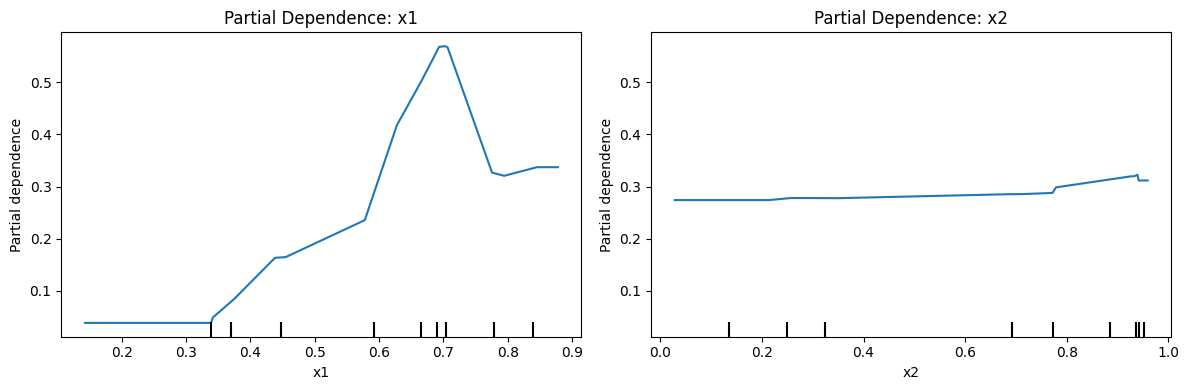

In [23]:
# =============================================================================
# FUNCTION 2 - Noisy Log-Likelihood (2D)
# changes: 
#     - switch surrogate to anisotropic GP, informed by RF diagnostics
#         pipeline: RF -> PDP -> compute input-scale variation -> GP length-scale bounds
#         PDP-derived length-scale bounds: input span measures the x-axis scale over the output changes 
#         to directly translate to Matern length-scale units
#     - GP posterior variance replaces RF tree std for theoretically grounded UCB.
#     - lowered kappa from 4.0 to 2.0 -- less exploration
#   note: in test x2 length scale was maxing out at any length from 10 to 100, possibly fix it for future iterations
# =============================================================================

print("\n" + "=" * 60)
print("Function 2 - Week 8")
print("=" * 60)

initial_inputs  = np.load('../Data/function_2/initial_inputs.npy')
initial_outputs = np.load('../Data/function_2/initial_outputs.npy')

prev_queries = np.array([
    [0.775510, 0.959184],  # W1: 0.166
    [0.683114, 0.932567],  # W2: 0.570
    [0.794441, 0.256481],  # W3: 0.273
    [0.706387, 0.952221],  # W4: 0.675 (best)
    [0.693183, 0.938929],  # W5: 0.674
    [0.374540, 0.950714],  # W6: 0.096 
    [0.627660, 0.941490],  # W7: 0.311
])
prev_outputs = np.array([0.16576674, 0.56974583, 0.27313450, 0.67545988, 0.67430262, 0.09612224849190841, 0.3113471043593484])

all_inputs  = np.vstack([initial_inputs, prev_queries])
all_outputs = np.hstack([initial_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}")
print(f"Current best: {all_outputs.max():.3f}")

# RF fitted for PDP computation only -- not used for acquisition
rf = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)
print(f"Feature importances: x1={rf.feature_importances_[0]:.3f}, x2={rf.feature_importances_[1]:.3f}")

# --- PDP-derived length-scale bounds ---
# compute PDP for each dimension programmatically
pd_x1 = partial_dependence(rf, all_inputs, features=[0], grid_resolution=100)
pd_x2 = partial_dependence(rf, all_inputs, features=[1], grid_resolution=100)

# extract input grid and output values
x1_grid   = pd_x1['grid_values'][0]
x1_pd     = pd_x1['average'][0]
x2_grid   = pd_x2['grid_values'][0]
x2_pd     = pd_x2['average'][0]

# find the input span over threshold to identify the active input region  
# considered active in regions where PDP exceeds 20% of its total range
x1_pd_range    = x1_pd.max() - x1_pd.min()
x2_pd_range    = x2_pd.max() - x2_pd.min()

x1_active      = x1_grid[x1_pd >= x1_pd.min() + 0.2 * x1_pd_range]
x2_active      = x2_grid[x2_pd >= x2_pd.min() + 0.2 * x2_pd_range]

x1_input_span  = x1_active.max() - x1_active.min() if len(x1_active) > 1 else 1.0
x2_input_span  = x2_active.max() - x2_active.min() if len(x2_active) > 1 else 1.0

print(f"\nPDP input spans: x1={x1_input_span:.3f}, x2={x2_input_span:.3f}")

# length-scale upper bound = input span (function varies over this scale)
# length-scale lower bound = small fraction of upper bound
x1_ls_upper = float(np.clip(x1_input_span, 0.1, 1.0))
x2_ls_upper = float(np.clip(x2_input_span, 0.1, 10.0))
x1_ls_lower = x1_ls_upper / 100
x2_ls_lower = x2_ls_upper / 100

print(f"Derived length-scale bounds: x1=({x1_ls_lower:.4f}, {x1_ls_upper:.3f}), x2=({x2_ls_lower:.4f}, {x2_ls_upper:.3f})")

# anisotropic GP with PDP-derived bounds and WhiteKernel
kernel = (Matern(length_scale=[x1_ls_upper / 2, x2_ls_upper / 2],
                 length_scale_bounds=[(x1_ls_lower, x1_ls_upper),
                                      (x2_ls_lower, x2_ls_upper)],
                 nu=2.5)
          + WhiteKernel(noise_level=0.01,
                        noise_level_bounds=(1e-6, 1.0)))

gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, normalize_y=True)
gp.fit(all_inputs, all_outputs)
print(f"Learned kernel: {gp.kernel_}")

# UCB using GP posterior variance - kappa 2.0
np.random.seed(42)
candidates       = np.random.uniform(0, 1, (50000, 2))
gp_mean, gp_std  = gp.predict(candidates, return_std=True)
kappa            = 2.0
ucb_scores       = gp_mean + kappa * gp_std

best_idx = np.argmax(ucb_scores)
query    = candidates[best_idx]

print(f"\nWeek 8 Query: {format_query(query)}")
print(f"  GP mean:   {gp_mean[best_idx]:.3f}")
print(f"  GP std:    {gp_std[best_idx]:.3f}")
print(f"  UCB score: {ucb_scores[best_idx]:.3f}  (kappa=2.0)")

# --- Interpretability: partial dependence plots ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
PartialDependenceDisplay.from_estimator(rf, all_inputs, features=[0, 1],
                                         feature_names=['x1', 'x2'], ax=axes)
axes[0].set_title('Partial Dependence: x1')
axes[1].set_title('Partial Dependence: x2')
plt.tight_layout()
plt.show()

# Function 3 - week 8


Function 3 - Week 8
Total points: 22, best: -0.0000607

RF feature importances:
  A     : 0.0963
  B     : 0.1487
  C     : 0.1564
  A*B   : 0.0529
  A*C   : 0.0645
  B*C   : 0.1264
  A^2   : 0.1584
  B^2   : 0.0828
  C^2   : 0.1137

RF train R²: 0.2794
RF train predictions vs actual:
  predicted: -0.095706, actual: -0.112122
  predicted: -0.088681, actual: -0.087963
  predicted: -0.099164, actual: -0.111415
  predicted: -0.050349, actual: -0.034835
  predicted: -0.069456, actual: -0.048008
  predicted: -0.080332, actual: -0.110621
  predicted: -0.095250, actual: -0.398926
  predicted: -0.090707, actual: -0.113869
  predicted: -0.092246, actual: -0.131461
  predicted: -0.092593, actual: -0.094190
  predicted: -0.072295, actual: -0.046947
  predicted: -0.080606, actual: -0.105965
  predicted: -0.087683, actual: -0.118048
  predicted: -0.085459, actual: -0.036378
  predicted: -0.069007, actual: -0.056758
  predicted: -0.051825, actual: -0.029062
  predicted: -0.063138, actual: -0.062310

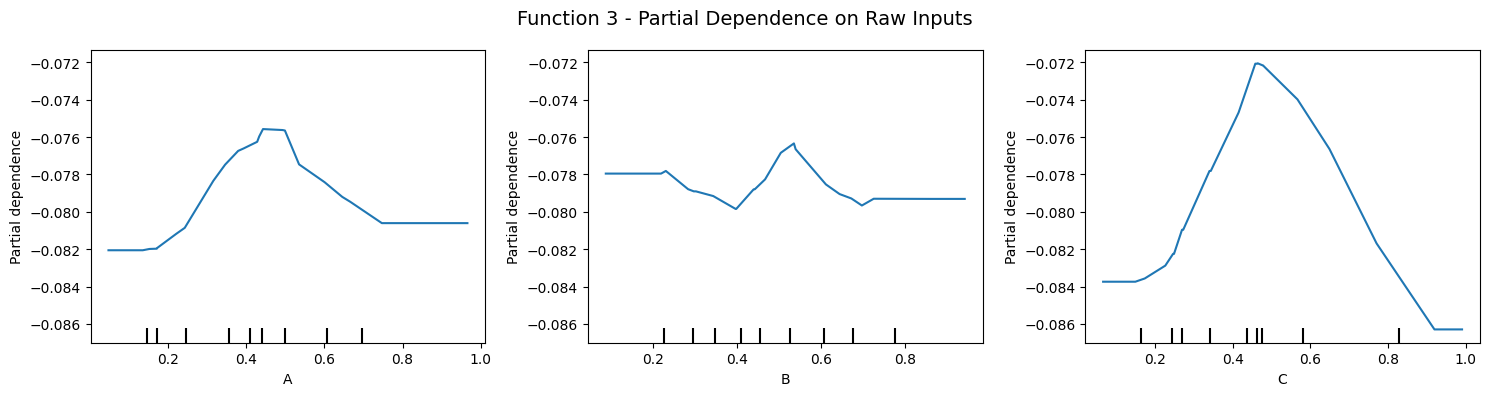

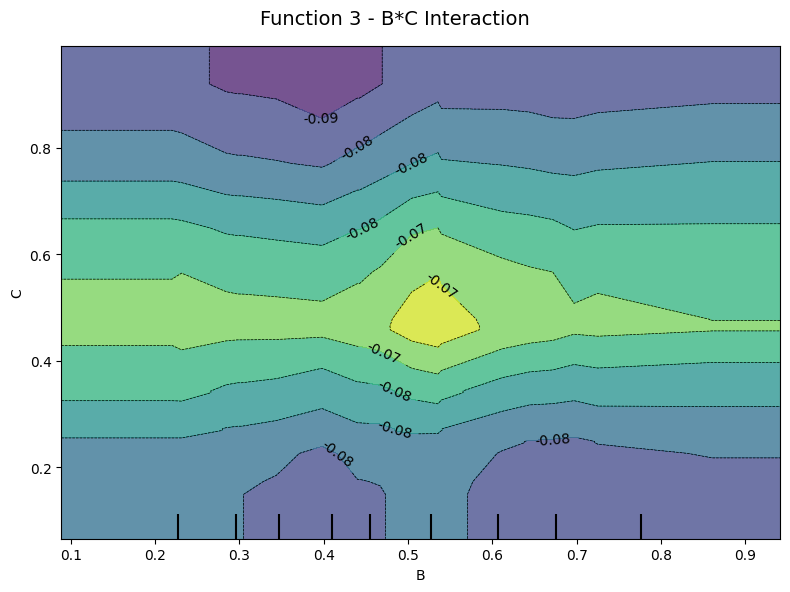

In [24]:
# =============================================================================
# FUNCTION 3 - Drug Discovery (3D)
# changes:
#   - added Weighted Least Squares (WLS) style sample weighting — w_i = 1 / residual_i^2
#      inverse residual weighting downweights high-error bulk points and upweights the stable peak region
#      addressing potential heteroscedasticity, since ExtraTrees surrogate underestimates best points by 37x 
#   - changed from UCB acquisition function to LCB to penalise high-uncertainty candidates
#   - added exclusion filter — removes candidates within 0.01 of training points.
#      required because ExtraTrees is likely overfitting, and choosing previously queried points
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 3 - Week 8")
print("=" * 60)
 
f3_inputs  = np.load('../Data/function_3/initial_inputs.npy')
f3_outputs = np.load('../Data/function_3/initial_outputs.npy')
 
prev_queries = np.array([
    [0.378956, 0.302768, 0.459346],  # W1: -0.0291
    [0.315339, 0.088659, 0.415174],  # W2: -0.0623
    [0.392735, 0.504381, 0.464332],  # W3: -0.000633
    [0.498607, 0.467046, 0.477827],  # W4: -0.00294
    [0.432840, 0.535542, 0.476983],  # W5: -0.000617
    [0.442511, 0.539648, 0.462840],  # W6: -0.0000607 (best)
    [0.427601, 0.442546, 0.649322],  # W7: -0.0906    
])
prev_outputs = np.array([
    -0.02906213067759293,
    -0.06230989251412482,
    -0.0006328364393800658,
    -0.0029446702316140265,
    -0.0006169444563794807,
    -0.00006071018004296725,
    -0.09063996317418548,
])
 
X = np.vstack([f3_inputs, prev_queries])
Y = np.hstack([f3_outputs, prev_outputs])
 
print(f"Total points: {len(Y)}, best: {Y.max():.7f}")
 
# --- Polynomial features (explicit compound interactions) ---
poly   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

# --- WLS weights ---
# Step 1: fit an unweighted model to estimate residuals at each training point
# Step 2: use squared residuals as variance estimates, weight = 1 / variance
rf_step1 = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_step1.fit(X_poly, Y)
residuals = Y - rf_step1.predict(X_poly)
local_variance = residuals ** 2
weights = 1 / (local_variance + 1e-9)  # 1e-9 prevents division by zero

# Step 2: refit with WLS weights
# high-residual (uncertain) points get lower weight
# low-residual (well-fit) points get higher weight
rf = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf.fit(X_poly, Y, sample_weight=weights)

# --- RF on polynomial features ---
print("\nRF feature importances:")
for name, imp in zip(feature_names, rf.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")

train_preds = rf.predict(X_poly)
print(f"\nRF train R2: {r2_score(Y, train_preds):.4f}")
print(f"RF train predictions vs actual:")
for pred, actual in zip(train_preds, Y):
    print(f"  predicted: {pred:.6f}, actual: {actual:.6f}")

# --- Global candidate search ---
np.random.seed(42)
candidates = np.random.uniform(0, 1, (10000, 3))

min_distance = 0.01
distances = np.min(np.linalg.norm(candidates[:, None, :] - X[None, :, :], axis=2), axis=1)
candidates = candidates[distances > min_distance]
cand_poly  = poly.transform(candidates)

cand_poly  = poly.transform(candidates)

tree_preds = np.array([tree.predict(cand_poly) for tree in rf.estimators_])
mean_pred  = tree_preds.mean(axis=0)
std_pred   = tree_preds.std(axis=0)

kappa  = 0.5
scores = mean_pred - kappa * std_pred
best_idx = np.argmax(scores)
query    = candidates[best_idx]

top_n = 10
top_indices = np.argsort(scores)[::-1][:top_n]
print(f"\nTop {top_n} RF candidates:")
for i, idx in enumerate(top_indices):
    print(f"  {i+1}: {format_query(candidates[idx])}, mean: {mean_pred[idx]:.6f}, std: {std_pred[idx]:.6f}, LCB: {scores[idx]:.6f}")

print(f"\nWeek 8 Query: {format_query(query)}")
print(f"  Ensemble mean: {mean_pred[best_idx]:.6f}")
print(f"  Tree std:      {std_pred[best_idx]:.6f}")
print(f"  LCB score:     {scores[best_idx]:.6f}  (kappa = {kappa})")
 
# --- Interpretability Plots ---
rf_raw = ExtraTreesRegressor(n_estimators=200, max_features='sqrt', min_samples_leaf=2, random_state=42)
rf_raw.fit(X, Y, sample_weight=weights)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[0, 1, 2],
                                         feature_names=['A', 'B', 'C'], ax=axes)
plt.suptitle('Function 3 - Partial Dependence on Raw Inputs', fontsize=14)
plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(8, 6))
PartialDependenceDisplay.from_estimator(rf_raw, X, features=[(1, 2)],
                                         feature_names=['A', 'B', 'C'], ax=[ax2])
plt.suptitle('Function 3 - B*C Interaction', fontsize=14)
plt.tight_layout()
plt.show()

# Function 4 - week 8


Function 4 - Week 8
Total points: 37, best: 0.6309

Candidates: 5000 W2 + 3000 W1 + 2000 W4 = 10000 total
LOO R² RF:  0.7414
LOO R² GP:  0.7271

RF Feature Importances:
  x1=0.283, 
  x2=0.376, 
  x3=0.102, 
  x4=0.239

Week 8 Query: 0.431511-0.415976-0.232614-0.411417
mean: -1.205
std:  3.408
UCB:  2.202514


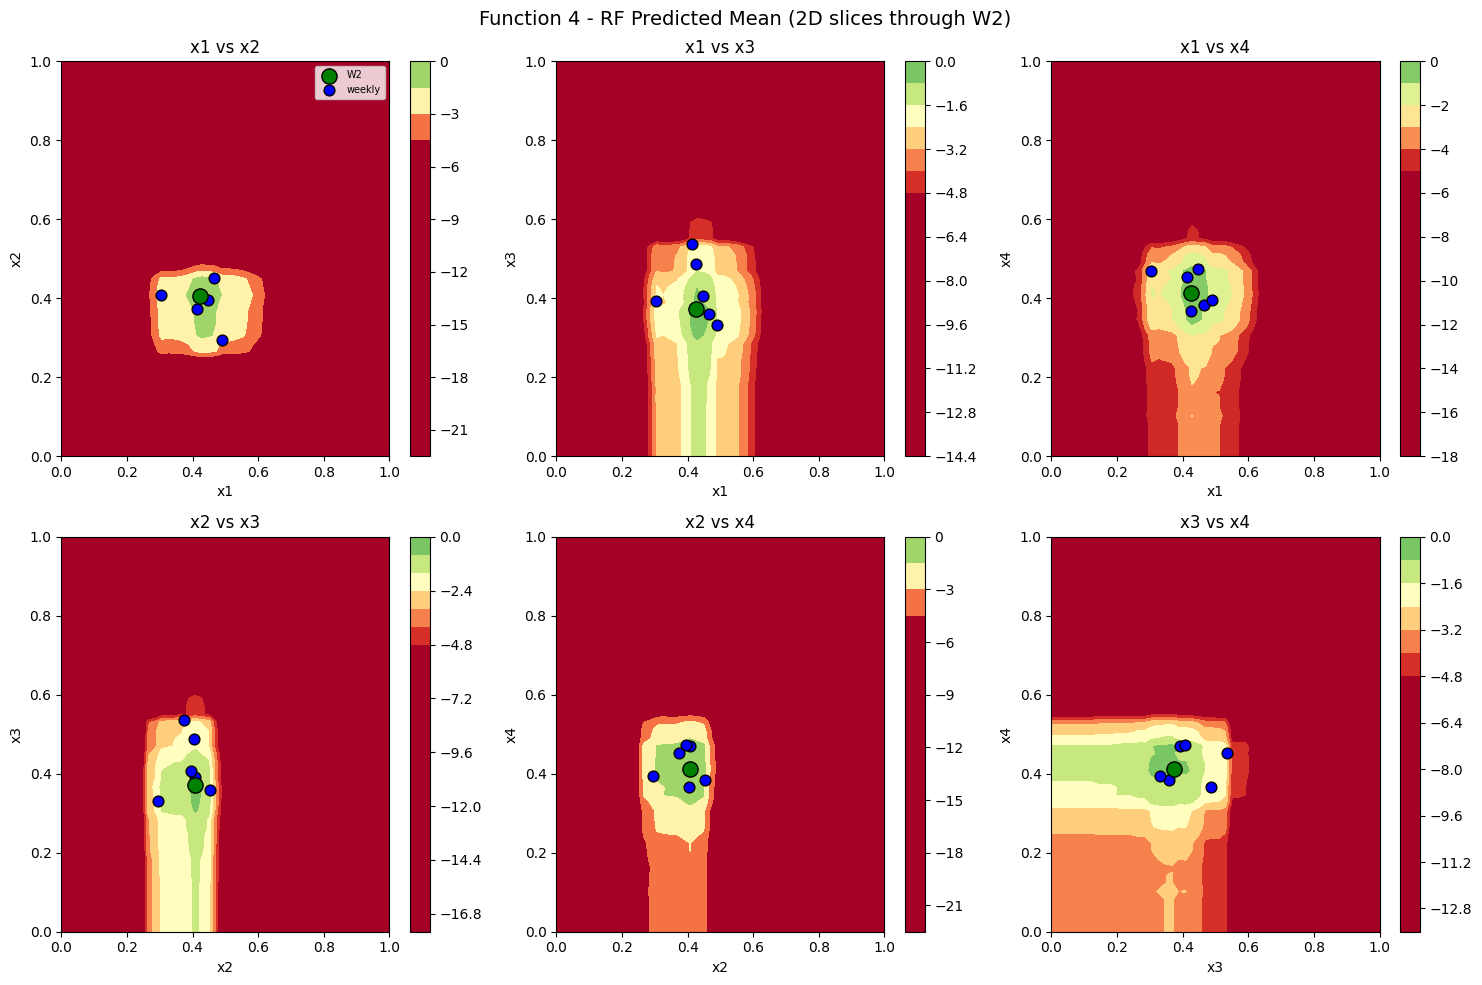

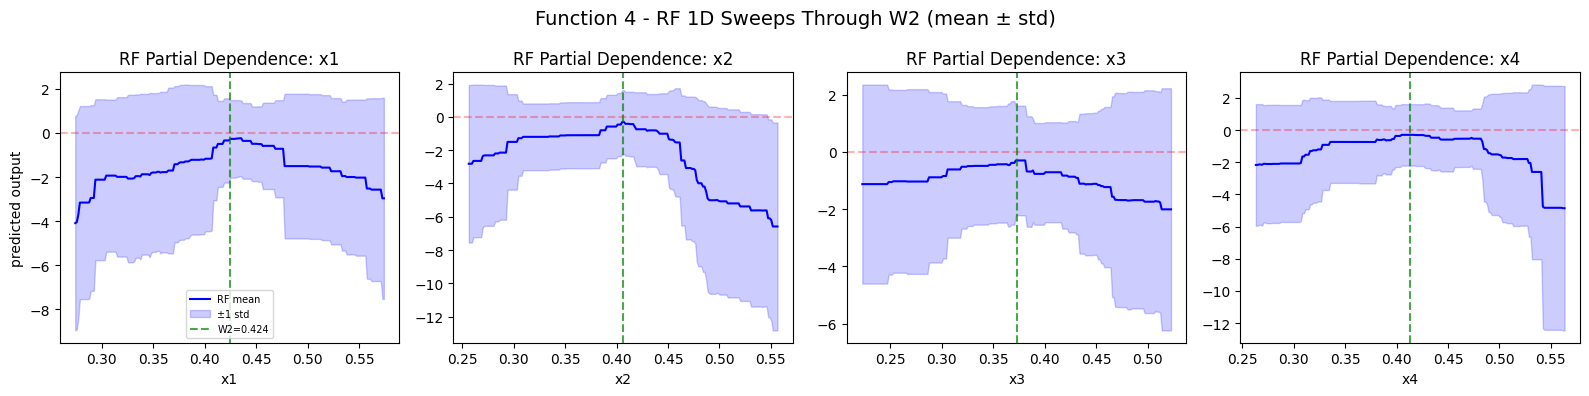

In [26]:
# =============================================================================
# FUNCTION 4 - Warehouse Placement (4D)
# changes:
#   - changed to RandomForest surrogate, replacing GP due to non-stationarity in the landscape.
#      Inspired by Hutter et al. 2011 (SMAC), RF partitions adaptively, so dimension interactions are more nuanced 
#      LOO R2 for RF (0.741) versus GP (0.727)
#   - removed SVM and replaced with candidates only around W1/W2/W4, 
#      the SVM was filtering <4% of candidates. Not enough positive examples for a reliable decision boundary
#   - changed acquisition function from EI to UCB (kappa = 1.0) 
#      RF tree variance overestimates uncertainty in sparse regions, causing EI to chase high variance.
#   - added interpretability RF feature importances, 2D predicted mean heatmaps, and 1D partial dependence through W2 
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 4 - Week 8")
print("=" * 60)
 
f4_inputs  = np.load('../Data/function_4/initial_inputs.npy')
f4_outputs = np.load('../Data/function_4/initial_outputs.npy')
 
prev_queries = np.array([
    [0.466173, 0.451984, 0.359193, 0.383111],  # W1: -0.965
    [0.424201, 0.406375, 0.372722, 0.413313],  # W2: +0.631 (best)
    [0.413541, 0.373697, 0.536536, 0.453354],  # W3: -2.150
    [0.424125, 0.404716, 0.487507, 0.367688],  # W4: -0.992
    [0.488793, 0.294975, 0.332280, 0.395576],  # W5: -2.463
    [0.303872, 0.408521, 0.392275, 0.469543],  # W6: -2.141
    [0.447976, 0.395249, 0.406174, 0.473345],  # W7: -1.249
])
prev_outputs = np.array([
    -0.9654345395220925, 0.6308582112564989, -2.1500998298742817,
    -0.9915950770116662, -2.4630197287139697, -2.1414388028868454,
    -1.2497635252595596,
])
 
f4_all_inputs  = np.vstack([f4_inputs, prev_queries])
f4_all_outputs = np.hstack([f4_outputs, prev_outputs])
print(f"Total points: {len(f4_all_outputs)}, best: {f4_all_outputs.max():.4f}")
 
# Candidate generation -- local search around best three query points
np.random.seed(42)

week1_query = np.array([0.466173, 0.451984, 0.359193, 0.383111])
week2_query = np.array([0.424201, 0.406375, 0.372722, 0.413313])
week4_query = np.array([0.424125, 0.404716, 0.487507, 0.367688])

candidates_w2 = np.array([np.clip(week2_query + np.random.normal(0, 0.03, 4), 0, 1) for _ in range(5000)])
candidates_w1 = np.array([np.clip(week1_query + np.random.normal(0, 0.05, 4), 0, 1) for _ in range(3000)])
candidates_w4 = np.array([np.clip(week4_query + np.random.normal(0, 0.05, 4), 0, 1) for _ in range(2000)])

candidates = np.vstack([candidates_w2, candidates_w1, candidates_w4])
print(f"\nCandidates: {len(candidates_w2)} W2 + {len(candidates_w1)} W1 + {len(candidates_w4)} W4 = {len(candidates)} total")

# --- RF Surrogate 
rf = RandomForestRegressor(n_estimators=500, random_state=42)
rf.fit(f4_all_inputs, f4_all_outputs)

loo = LeaveOneOut()
loo_predictions = np.zeros(len(f4_all_outputs))

for train_idx, test_idx in loo.split(f4_all_inputs):
    rf_loo = RandomForestRegressor(n_estimators=500, random_state=42)
    rf_loo.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
    loo_predictions[test_idx] = rf_loo.predict(f4_all_inputs[test_idx])

loo_r2 = r2_score(f4_all_outputs, loo_predictions)
print(f"LOO R2 RF:  {loo_r2:.4f}")

# ---- compare with GP
loo_predictions_gp = np.zeros(len(f4_all_outputs))

for train_idx, test_idx in loo.split(f4_all_inputs):
    kernel = ConstantKernel(1.0, (1e-3, 1e3)) * Matern(
        length_scale=[0.3, 0.3, 0.2, 0.3],
        length_scale_bounds=[(0.1, 2.0), (0.1, 2.0), (0.1, 0.5), (0.1, 2.0)],
        nu=2.5
    )
    gp_loo = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=20, alpha=1e-4, normalize_y=True)
    gp_loo.fit(f4_all_inputs[train_idx], f4_all_outputs[train_idx])
    loo_predictions_gp[test_idx] = gp_loo.predict(f4_all_inputs[test_idx])

loo_r2_gp = r2_score(f4_all_outputs, loo_predictions_gp)
print(f"LOO R2 GP:  {loo_r2_gp:.4f}")

# --- RF Feature Importances
print(f"\nRF Feature Importances:")
print(f"  x1={rf.feature_importances_[0]:.3f}, \n  x2={rf.feature_importances_[1]:.3f}, "
      f"\n  x3={rf.feature_importances_[2]:.3f}, \n  x4={rf.feature_importances_[3]:.3f}")

# RF predictions -- mean and std across individual trees
tree_predictions = np.array([tree.predict(candidates) for tree in rf.estimators_])
mu = tree_predictions.mean(axis=0)
sigma = tree_predictions.std(axis=0)

# UCB acquisition
kappa = 1.0
ucb = mu + kappa * sigma

best_index = np.argmax(ucb)
query = candidates[best_index]

print(f"\nWeek 8 Query: {format_query(query)}")
print(f"mean: {mu[best_index]:.3f}")
print(f"std:  {sigma[best_index]:.3f}")
print(f"UCB:  {ucb[best_index]:.6f}")
 
# --- Interpretability plots ---
# 2D RF predicted mean -- sweep pairs of dimensions through W2
dim_names = ['x1', 'x2', 'x3', 'x4']
pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, (d1, d2) in enumerate(pairs):
    ax = axes[idx]
    res = 50
    v1 = np.linspace(0, 1, res)
    v2 = np.linspace(0, 1, res)
    grid = np.tile(week2_query, (res * res, 1))
    g1, g2 = np.meshgrid(v1, v2)
    grid[:, d1] = g1.ravel()
    grid[:, d2] = g2.ravel()

    pred = rf.predict(grid).reshape(res, res)
    contour = ax.contourf(v1, v2, pred, levels=20, cmap='RdYlGn', vmin=-5, vmax=1)
    plt.colorbar(contour, ax=ax)

    # plot W2 and other queries
    ax.scatter(week2_query[d1], week2_query[d2], c='green', edgecolors='black', s=120, zorder=5, label='W2')
    ax.scatter(prev_queries[:, d1], prev_queries[:, d2], c='blue', edgecolors='black', s=60, zorder=4, label='weekly')

    ax.set_xlabel(dim_names[d1])
    ax.set_ylabel(dim_names[d2])
    ax.set_title(f'{dim_names[d1]} vs {dim_names[d2]}')

axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - RF Predicted Mean (2D slices through W2)', fontsize=14)
plt.tight_layout()
plt.show()

# RF 1D partial dependence through W2 -- shows basin shape per dimension
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, ax in enumerate(axes):
    sweep = np.linspace(week2_query[i] - 0.15, week2_query[i] + 0.15, 200)    
    test_points = np.tile(week2_query, (200, 1))
    test_points[:, i] = sweep

    sweep_preds = np.array([tree.predict(test_points) for tree in rf.estimators_])
    sweep_mu = sweep_preds.mean(axis=0)
    sweep_std = sweep_preds.std(axis=0)

    ax.plot(sweep, sweep_mu, 'b-', label='RF mean')
    ax.fill_between(sweep, sweep_mu - sweep_std, sweep_mu + sweep_std, alpha=0.2, color='blue', label='±1 std')
    ax.axvline(x=week2_query[i], color='green', linestyle='--', alpha=0.7, label=f'W2={week2_query[i]:.3f}')
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.3)
    ax.set_xlabel(dim_names[i])
    ax.set_ylabel('predicted output' if i == 0 else '')
    ax.set_title(f'RF Partial Dependence: {dim_names[i]}')
axes[0].legend(fontsize=7)
plt.suptitle('Function 4 - RF 1D Sweeps Through W2 (mean ± std)', fontsize=14)
plt.tight_layout()
plt.show()

# Function 5 - week 8


Function 5 - Week 8
Total points: 27, best so far: 5255.71

Week 8 Query:       0.798393-0.999999-0.999999-0.999999
GP predicted yield: 5302.07
GP std (log scale): 0.2415
SVR prediction:     5305.62
EI:                 0.098258

--- GP vs SVR at historical queries ---
Week       Actual    GP pred   SVR pred
W1         2201.8     2201.8     2217.3
W2         2381.5     2381.5     2385.2
W3         2689.2     2689.2     2673.5
W4         3223.2     3223.2     3238.5
W5         3287.0     3287.0     3271.8
W6         4354.1     4354.1     4338.4
W7         5255.7     5255.7     5270.7

--- x1 sensitivity check ---
    x1   GP yield  SVR yield
  0.40     4299.6     4164.9
  0.50     4568.5     4486.2
  0.55     4752.4     4709.2
  0.60     4959.1     4948.0
  0.65     5156.7     5165.3
  0.70     5301.8     5318.9
  0.75     5356.0     5371.8
  0.80     5298.4     5301.3

--- x2 sensitivity check ---
    x2   GP yield  SVR yield
  0.85     3467.2     3978.6
  0.90     4029.9     4443.3
  

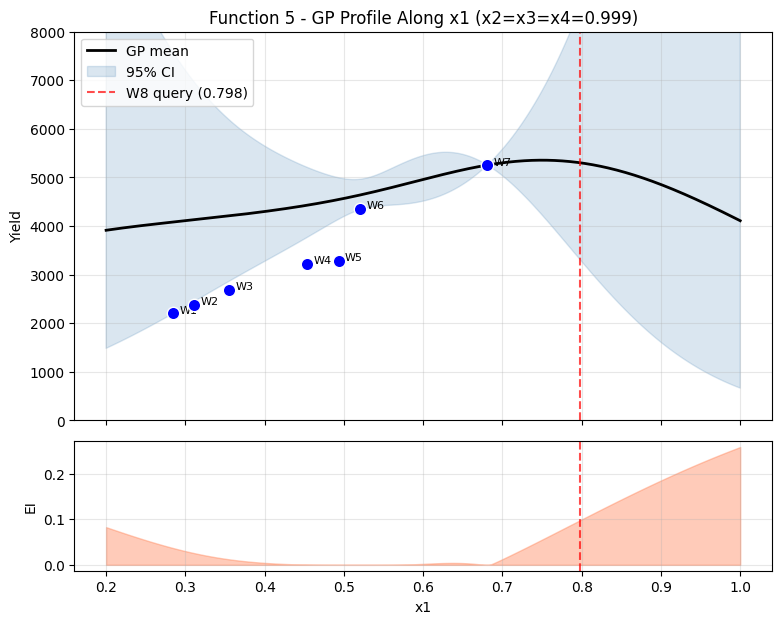

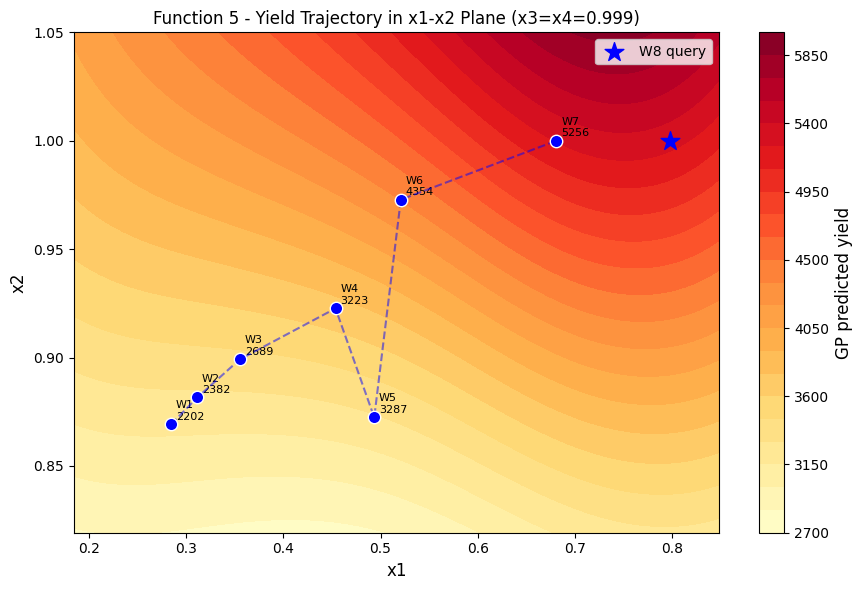

In [28]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
#   seventh consecutive improvement, so kept the overall pipeline.
# changes: 
#    - SVR was underpredicting by 150 consistently, so changed epsilon to 0.01
#    - added interpretability plot for GP profile along x1 with uncertainty and EI
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 5 - Week 8")
print("=" * 60)
 
f5_inputs  = np.load('../Data/function_5/initial_inputs.npy')
f5_outputs = np.load('../Data/function_5/initial_outputs.npy')
 
prev_queries = np.array([
    [0.284290, 0.869208, 0.999999, 0.903273],  # W1: 2201.83
    [0.311208, 0.881577, 0.999999, 0.915050],  # W2: 2381.54
    [0.355085, 0.899160, 0.999900, 0.934196],  # W3: 2689.15
    [0.453609, 0.922659, 0.999999, 0.960267],  # W4: 3223.24
    [0.493503, 0.872392, 0.999999, 0.999999],  # W5: 3286.99
    [0.520874, 0.972838, 0.999999, 0.999999],  # W6: 4354.08
    [0.681041, 0.999999, 0.999999, 0.999999],  # W7: 5255.70
])
prev_outputs = np.array([
    2201.834589108927, 2381.536867607932, 2689.1537294933396,
    3223.2410694936825, 3286.9929500236235, 4354.076520735467,
    5255.707269541747
])
 
all_inputs  = np.vstack([f5_inputs, prev_queries])
all_outputs = np.hstack([f5_outputs, prev_outputs])
 
print(f"Total points: {len(all_outputs)}, best so far: {all_outputs.max():.2f}")
 
# SVR -- changed epslion
input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs)
Y_scaled = output_scaler.fit_transform(all_outputs.reshape(-1, 1)).ravel()
 
svr = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.01)
svr.fit(X_scaled, Y_scaled)
 
# GP on log-transformed outputs -- same as W6
y_log     = np.log1p(all_outputs)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp        = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp.fit(all_inputs, y_log)
 
best_point = all_inputs[np.argmax(all_outputs)]
np.random.seed(42)
 
# local candidates -- same as W6 with x3+x4 pinned
local = []
for _ in range(6000):
    c    = best_point + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    c[3] = 0.999999  # x4 pinned
    local.append(c)
 
# directed candidates -- x1 UP, x2 symmetric, x3+x4 pinned
directed = []
for _ in range(4000):
    c    = best_point.copy()
    c[0] = np.clip(c[0] + abs(np.random.normal(0, 0.05)), 0, 1)  # x1 up
    c[1] = np.clip(c[1] + np.random.normal(0, 0.03), 0, 1)        # x2 symmetric
    c[2] = 0.999999
    c[3] = 0.999999
    directed.append(c)
 
candidates = np.vstack([local, directed])
 
# SVR pre-filter: top 3000
X_cand_scaled = input_scaler.transform(candidates)
svr_preds_s   = svr.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()
 
top_idx  = np.argsort(svr_preds)[-3000:]
filtered = candidates[top_idx]
 
# GP + EI on log scale
mu_log, sigma_log = gp.predict(filtered, return_std=True)
ei                = compute_ei(mu_log, sigma_log, np.log1p(all_outputs.max()), xi=0.005)
 
best_idx = np.argmax(ei)
query    = filtered[best_idx]
 
print(f"\nWeek 8 Query:       {format_query(query)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx]:.4f}")
print(f"SVR prediction:     {svr_preds[top_idx[best_idx]]:.2f}")
print(f"EI:                 {ei[best_idx]:.6f}")
 
# --- Interpretability ---
# --- GP vs SVR comparison at all query points 
print("\n--- GP vs SVR at historical queries ---")
print(f"{'Week':<6} {'Actual':>10} {'GP pred':>10} {'SVR pred':>10}")
for i, (q, actual) in enumerate(zip(prev_queries, prev_outputs)):
    gp_pred  = np.expm1(gp.predict(q.reshape(1, -1))[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(q.reshape(1, -1))).reshape(-1, 1)
    ).ravel()[0]
    print(f"W{i+1:<5} {actual:>10.1f} {gp_pred:>10.1f} {svr_pred:>10.1f}")
 
# --- stats and plots 
# check what GP and SVR predict at different values
print("\n--- x1 sensitivity check ---")
print(f"{'x1':>6} {'GP yield':>10} {'SVR yield':>10}")
for x1_val in [0.40, 0.50, 0.55, 0.60, 0.65, 0.70, 0.75, 0.80]:
    test_point = np.array([[x1_val, 0.999999, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x1_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")


# check x2
print("\n--- x2 sensitivity check ---")
print(f"{'x2':>6} {'GP yield':>10} {'SVR yield':>10}")
for x2_val in [0.85, 0.90, 0.92, 0.95, 0.97, 0.99, 1.00]:
    test_point = np.array([[best_point[0], x2_val, 0.999999, 0.999999]])
    gp_pred = np.expm1(gp.predict(test_point)[0])
    svr_pred = output_scaler.inverse_transform(
        svr.predict(input_scaler.transform(test_point)).reshape(-1, 1)
    ).ravel()[0]
    print(f"{x2_val:>6.2f} {gp_pred:>10.1f} {svr_pred:>10.1f}")
    
# --- Plot 1: GP profile along x1 with uncertainty and EI ---
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9, 7),
                                sharex=True, gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.08})

x1_sweep = np.linspace(0.2, 1.0, 500)
sweep_4d = np.column_stack([x1_sweep,
                            np.full(500, 0.999999),
                            np.full(500, 0.999999),
                            np.full(500, 0.999999)])

mu_sweep, sigma_sweep = gp.predict(sweep_4d, return_std=True)
yield_mean = np.expm1(mu_sweep)
yield_upper = np.expm1(mu_sweep + 1.96 * sigma_sweep)
yield_lower = np.expm1(mu_sweep - 1.96 * sigma_sweep)

# top panel: GP mean + uncertainty
ax1.plot(x1_sweep, yield_mean, 'k-', linewidth=2, label='GP mean')
ax1.fill_between(x1_sweep, yield_lower, yield_upper, alpha=0.2, color='steelblue',
                 label='95% CI')

# overlay query history
for i in range(len(prev_queries)):
    ax1.scatter(prev_queries[i, 0], prev_outputs[i], c='blue',
                edgecolors='white', s=80, zorder=5)
    ax1.annotate(f'W{i+1}', (prev_queries[i, 0] + 0.008, prev_outputs[i]),
                 fontsize=8)

ax1.axvline(query[0], color='red', linestyle='--', alpha=0.7, label=f'W8 query ({query[0]:.3f})')
ax1.set_ylim(0, 8000)
ax1.set_ylabel('Yield')
ax1.set_title('Function 5 - GP Profile Along x1 (x2=x3=x4=0.999)')
ax1.legend(loc='upper left')
ax1.grid(True, alpha=0.3)

# bottom panel: EI
ei_sweep = compute_ei(mu_sweep, sigma_sweep, np.log1p(all_outputs.max()), xi=0.005)
ax2.fill_between(x1_sweep, 0, ei_sweep, alpha=0.4, color='coral')
ax2.axvline(query[0], color='red', linestyle='--', alpha=0.7)
ax2.set_xlabel('x1')
ax2.set_ylabel('EI')
ax2.grid(True, alpha=0.3)

#plt.tight_layout()
plt.show()

# --- Plot 2: Fixed contour with correct x1 range ---
pad = 0.05
x1_min = min(prev_queries[:, 0].min(), query[0]) - 0.1
x1_max = max(prev_queries[:, 0].max(), query[0]) + pad
x2_min = min(prev_queries[:, 1].min(), query[1]) - pad
x2_max = max(prev_queries[:, 1].max(), query[1]) + pad

grid_n = 80
x1_range = np.linspace(x1_min, x1_max, grid_n)
x2_range = np.linspace(x2_min, x2_max, grid_n)
X1_g, X2_g = np.meshgrid(x1_range, x2_range)

grid_4d = np.column_stack([X1_g.ravel(), X2_g.ravel(),
                           np.full(grid_n**2, 0.999999),
                           np.full(grid_n**2, 0.999999)])
mu_grid = np.expm1(gp.predict(grid_4d))
mu_grid = mu_grid.reshape(grid_n, grid_n)

fig, ax = plt.subplots(figsize=(9, 6))
cf = ax.contourf(X1_g, X2_g, mu_grid, levels=20, cmap='YlOrRd')
cbar = fig.colorbar(cf)
cbar.set_label('GP predicted yield', fontsize=12)

for i in range(len(prev_queries)):
    ax.scatter(prev_queries[i, 0], prev_queries[i, 1], c='blue',
               edgecolors='white', s=80, zorder=5)
    ax.annotate(f'W{i+1}\n{prev_outputs[i]:.0f}',
                (prev_queries[i, 0] + 0.005, prev_queries[i, 1] + 0.002), fontsize=8)
ax.plot(prev_queries[:, 0], prev_queries[:, 1], 'b--', alpha=0.5, zorder=4)
ax.scatter(query[0], query[1], marker='*', c='blue', s=200, zorder=10, label='W8 query')

ax.set_xlim(x1_min, x1_max)
ax.set_ylim(x2_min, x2_max)
ax.set_xlabel('x1', fontsize=12)
ax.set_ylabel('x2', fontsize=12)
ax.set_title('Function 5 - Yield Trajectory in x1-x2 Plane (x3=x4=0.999)')
ax.legend()
fig.tight_layout()
plt.show()

# Function 6 - week 8


Function 6 - Week 8
Total observations: 27, best so far: -0.3148

Multi-surrogate LOO comparison
surrogate              MAE      R² MSE at top3
--------------------------------------------
RF d=5              0.2803  0.5794    +0.4032
RF d=None           0.2803  0.5794    +0.4028
GBR d=3             0.2486  0.6987    +0.2821
GBR d=5             0.3501  0.3925    +0.2576
KNN k=3             0.2830  0.5387    +0.0854
KNN k=5             0.3131  0.4861    +0.1841
SVR rbf             0.1693  0.8086    +0.1770
SVR rbf C=10        0.1688  0.8094    +0.1729

Week 8 Query (SVR): 0.482908-0.318128-0.672147-0.855190-0.203478
  Predicted value: -0.3757


/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_96038/388168720.py:181: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, all_inputs,


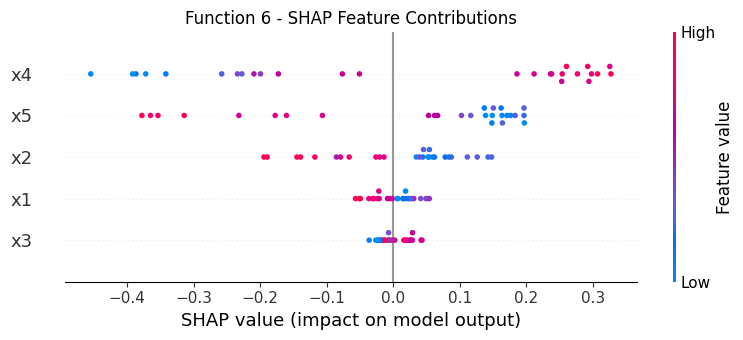

In [29]:
# =============================================================================
# FUNCTION 6 - Cake Recipe (5D)
# changes: 
#    - replaced RF surrogate (averaging compresses predictions) with SVR (with RBF kernel at C=10)
#       based on LOO comparison across RF, GBR, KNN, SVR 
#       SVR was dominant: R2 = 0.81, MAE = 0.17, MSE@top3 = 0.17
#    - RF retained for SHAP interpretability only - plot on RF (supplementary analysis)
# =============================================================================
 
print("\n" + "=" * 60)
print("Function 6 - Week 8")
print("=" * 60)
 
f6_inputs  = np.load('../Data/function_6/initial_inputs.npy')
f6_outputs = np.load('../Data/function_6/initial_outputs.npy')
 
prev_queries = np.array([
    [0.201818, 0.220639, 0.476414, 0.867793, 0.023115],  # W1: -0.792
    [0.457382, 0.349799, 0.529520, 0.691032, 0.192589],  # W2: -0.362
    [0.503404, 0.328861, 0.662838, 0.995031, 0.025514],  # W3: -0.368
    [0.484266, 0.300747, 0.678836, 0.776480, 0.244496],  # W4: -0.315 (best)
    [0.341066, 0.113474, 0.924694, 0.877339, 0.257942],  # W5: -0.829
    [0.408506, 0.262542, 0.745611, 0.998966, 0.244739],  # W6: -0.563
    [0.896209, 0.283983, 0.594508, 0.806739, 0.008612],  # W7: -0.764
])
prev_outputs = np.array([-0.792246, -0.361637, -0.367626, -0.314817, -0.828981, -0.5633934601648388, -0.764298611557724])
 
all_inputs  = np.vstack([f6_inputs, prev_queries])
all_outputs = np.hstack([f6_outputs, prev_outputs])
 
print(f"Total observations: {all_inputs.shape[0]}, best so far: {all_outputs.max():.4f}")
 
# --- Multi-surrogate LOO comparison ---

loo = LeaveOneOut()
best_pts = np.argsort(all_outputs)[-3:]

surrogates = {
    "RF d=5":        RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42),
    "RF d=None":     RandomForestRegressor(n_estimators=500, min_samples_leaf=2, random_state=42),
    "GBR d=3":       GradientBoostingRegressor(n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42),
    "GBR d=5":       GradientBoostingRegressor(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=42),
    "KNN k=3":       KNeighborsRegressor(n_neighbors=3, weights='distance'),
    "KNN k=5":       KNeighborsRegressor(n_neighbors=5, weights='distance'),
    "SVR rbf":       Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf'))]),
    "SVR rbf C=10":  Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=10))]),
}

print("\nMulti-surrogate LOO comparison")
print(f"{'surrogate':<18} {'MAE':>7} {'R2':>7} {'MSE at top3':>10}")
print("-" * 44)

for name, model in surrogates.items():
    loo_preds = np.zeros(len(all_outputs))
    for train_idx, test_idx in loo.split(all_inputs):
        model.fit(all_inputs[train_idx], all_outputs[train_idx])
        loo_preds[test_idx] = model.predict(all_inputs[test_idx].reshape(1, -1))[0]

    errors = all_outputs - loo_preds
    mae = np.mean(np.abs(errors))
    r2 = 1 - np.sum(errors**2) / np.sum((all_outputs - all_outputs.mean())**2)
    mse_top3 = errors[best_pts].mean()
    print(f"{name:<18} {mae:>7.4f} {r2:>7.4f} {mse_top3:>+10.4f}")
 
# --- SVR new surrogate based on multi-surrgoate LOO comparision ---
svr = Pipeline([('scl', StandardScaler()), ('svr', SVR(kernel='rbf', C=10))])
svr.fit(all_inputs, all_outputs)

space      = Space([(0.0, 1.0)] * 5)
lhs        = Lhs(criterion="maximin", iterations=100)
candidates = np.array(lhs.generate(space.dimensions, 5000))

svr_preds = svr.predict(candidates)
best_index = np.argmax(svr_preds)
query = candidates[best_index]

print(f"\nWeek 8 Query (SVR): {format_query(query)}")
print(f"  Predicted value: {svr_preds[best_index]:.4f}")
 
# --- Interpretability: SHAP summary plot ---
# --- RF for SHAP
rf = RandomForestRegressor(n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42)
rf.fit(all_inputs, all_outputs)

# --- testing RF's robusticity
# # --- LOO grid: max_depth × interaction features ---

# poly = PolynomialFeatures(degree=2, interaction_only=True, include_bias=False)
# all_inputs_aug = poly.fit_transform(all_inputs)

# loo = LeaveOneOut()
# depths = [3, 5, 8, None]
# input_sets = [("raw", all_inputs), ("augmented", all_inputs_aug)]

# print("\nLOO Grid: max_depth × feature set")
# print(f"{'config':<20} {'MAE':>7} {'R2':>7} {'MSE at top3':>10}")
# print("-" * 46)

# best_pts = np.argsort(all_outputs)[-3:]  # indices of 3 best observations

# for feat_name, X in input_sets:
#     for d in depths:
#         loo_preds = np.zeros(len(all_outputs))
#         for train_idx, test_idx in loo.split(X):
#             rf_loo = RandomForestRegressor(
#                 n_estimators=500, max_depth=d, min_samples_leaf=2, random_state=42
#             )
#             rf_loo.fit(X[train_idx], all_outputs[train_idx])
#             loo_preds[test_idx] = rf_loo.predict(X[test_idx])

#         errors = all_outputs - loo_preds
#         mae = np.mean(np.abs(errors))
#         r2 = 1 - np.sum(errors**2) / np.sum((all_outputs - all_outputs.mean())**2)
#         MSE_top3 = errors[best_pts].mean()

#         label = f"{feat_name}/d={d}"
#         print(f"{label:<20} {mae:>7.4f} {r2:>7.4f} {MSE_top3:>+10.4f}")

# # --- Percentile LOO diagnostic ---

# loo = LeaveOneOut()
# best_pts = np.argsort(all_outputs)[-3:]
# percentiles = [50, 65, 75, 85]

# # collect full tree-level predictions under LOO
# tree_preds_loo = np.zeros((len(all_outputs), 500))
# for train_idx, test_idx in loo.split(all_inputs):
#     rf_loo = RandomForestRegressor(
#         n_estimators=500, max_depth=5, min_samples_leaf=2, random_state=42
#     )
#     rf_loo.fit(all_inputs[train_idx], all_outputs[train_idx])
#     for t, tree in enumerate(rf_loo.estimators_):
#         tree_preds_loo[test_idx[0], t] = tree.predict(all_inputs[test_idx])[0]

# print("\nPercentile LOO diagnostic")
# print(f"{'percentile':<12} {'MAE':>7} {'R2':>7} {'MSE at top3':>10}")
# print("-" * 38)

# for p in percentiles:
#     preds = np.percentile(tree_preds_loo, p, axis=1)
#     errors = all_outputs - preds
#     mae = np.mean(np.abs(errors))
#     r2 = 1 - np.sum(errors**2) / np.sum((all_outputs - all_outputs.mean())**2)
#     mse_top3 = errors[best_pts].mean()
#     print(f"p={p:<10d} {mae:>7.4f} {r2:>7.4f} {mse_top3:>+10.4f}")

# # --- Weighted vs unweighted LOO comparison ---
# from sklearn.model_selection import LeaveOneOut

# loo = LeaveOneOut()
# best_pts = np.argsort(all_outputs)[-3:]

# print("\nWeighted vs Unweighted LOO")
# print(f"{'config':<25} {'MAE':>7} {'R2':>7} {'MSE@top3':>10}")
# print("-" * 51)

# for label, use_weights in [("unweighted", False), ("rank-weighted", True)]:
#     for d in [5, None]:
#         loo_preds = np.zeros(len(all_outputs))
#         for train_idx, test_idx in loo.split(all_inputs):
#             ranks = np.argsort(np.argsort(all_outputs[train_idx])).astype(float) + 1
#             w = ranks / ranks.sum() if use_weights else None
#             rf_loo = RandomForestRegressor(
#                 n_estimators=500, max_depth=d, min_samples_leaf=2, random_state=42
#             )
#             rf_loo.fit(all_inputs[train_idx], all_outputs[train_idx], sample_weight=w)
#             loo_preds[test_idx] = rf_loo.predict(all_inputs[test_idx])

#         errors = all_outputs - loo_preds
#         mae = np.mean(np.abs(errors))
#         r2 = 1 - np.sum(errors**2) / np.sum((all_outputs - all_outputs.mean())**2)
#         mse_top3 = errors[best_pts].mean()
#         config = f"{label}/d={d}"
#         print(f"{config:<25} {mae:>7.4f} {r2:>7.4f} {mse_top3:>+10.4f}")

explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(all_inputs)
 
plt.figure(figsize=(8, 5))
shap.summary_plot(shap_values, all_inputs,
                  feature_names=[f'x{i+1}' for i in range(5)], show=False)
plt.title('Function 6 - SHAP Feature Contributions')
plt.tight_layout()
plt.show()

# Function 7 - week 8


Function 7 - Week 8
Total points: 37, best: 2.6016

Step 1a: Full-dataset Random Forest

Full-dataset RF importance:
  HP1: 0.639
  HP2: 0.116
  HP3: 0.046
  HP4: 0.032
  HP5: 0.062
  HP6: 0.104

Step 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)
Points with HP1 < 0.1: 11
Output range in subset: 0.008 to 2.602

Filtered RF importance:
  HP1: 0.162  (was 0.639 in full dataset) ***
  HP2: 0.336  (was 0.116 in full dataset) ***
  HP3: 0.067  (was 0.046 in full dataset) 
  HP4: 0.124  (was 0.032 in full dataset) 
  HP5: 0.150  (was 0.062 in full dataset) 
  HP6: 0.161  (was 0.104 in full dataset) 

Permutation vs impurity importance (full dataset):
  Feature    Impurity  Permutation   Perm std
  HP1           0.639        1.088      0.213
  HP2           0.116        0.091      0.020
  HP3           0.046        0.029      0.006
  HP4           0.032        0.020      0.006
  HP5           0.062        0.050      0.010
  HP6           0.104        0.092      0.021

Permutation vs i

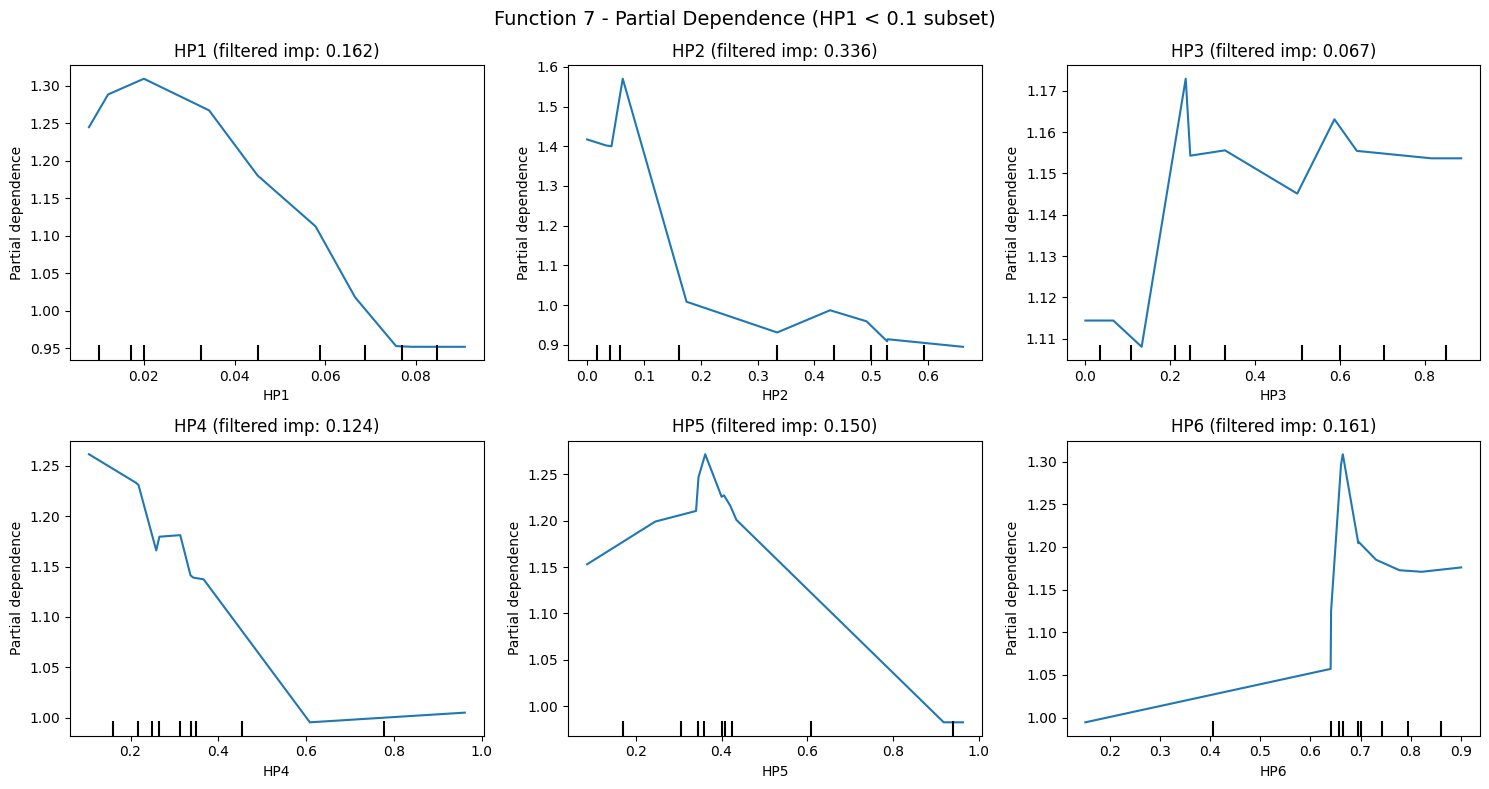

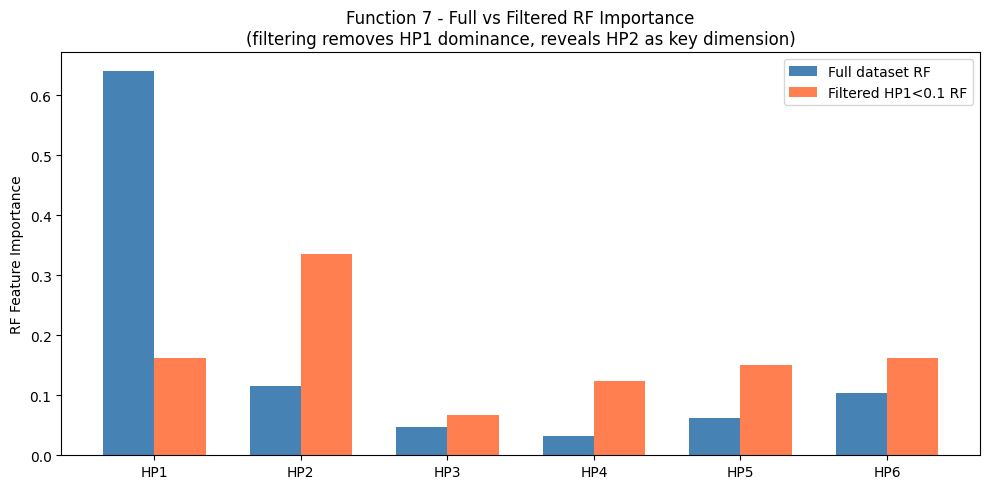

In [30]:
# =============================================================================
# FUNCTION 7 - ML Hyperparameters (6D)
# changes: 
#   - replace conversion of RF feature knowledge into per-feature bounds with sequential RF
#    two-RF structure from W7 is preserved (to encode interaction structure through tree splits):
#      - full-dataset RF (37 pts): filters out obviously bad candidates (high HP1, etc.)
#      - filtered RF (HP1 < 0.1): discriminates on HP2-HP5 within the promising region
#   - kappa reduced from 2.0 to 1.5, less exploration needed
# =============================================================================

print("\n" + "=" * 60)
print("Function 7 - Week 8")
print("=" * 60)

f7_inputs  = np.load('../Data/function_7/initial_inputs.npy')
f7_outputs = np.load('../Data/function_7/initial_outputs.npy')

prev_queries = np.array([
    [0.045091, 0.528666, 0.329265, 0.105350, 0.434671, 0.641164],  # W1: 1.051
    [0.034389, 0.427542, 0.236649, 0.342956, 0.405706, 0.695527],  # W2: 1.653
    [0.020000, 0.062635, 0.587368, 0.313225, 0.362008, 0.664539],  # W3: 2.602 (best)
    [0.012096, 0.033240, 0.640160, 0.336533, 0.245422, 0.901043],  # W4: 1.509
    [0.007872, 0.174935, 0.499616, 0.265730, 0.340533, 0.150339],  # W5: 0.383
    [0.020000, 0.000000, 0.000000, 0.212520, 0.346351, 0.696182],  # W6: 1.790
    [0.079160, 0.042812, 0.886277, 0.366485, 0.400229, 0.661016],  # W7: 1.429
])
prev_outputs = np.array([
    1.0510006614196026, 1.6531363312716738, 2.6016443512251484,
    1.5087286481808686, 0.3832671270292543, 1.789927976010441,
    1.428502150382287,
])

all_inputs  = np.vstack([f7_inputs, prev_queries])
all_outputs = np.hstack([f7_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f}")

feature_names = [f"HP{i+1}" for i in range(6)]

# Step 1a: Full-dataset Random Forest
print("\nStep 1a: Full-dataset Random Forest")
rf_full = RandomForestRegressor(n_estimators=200, random_state=42)
rf_full.fit(all_inputs, all_outputs)

print("\nFull-dataset RF importance:")
for name, imp in zip(feature_names, rf_full.feature_importances_):
    print(f"  {name}: {imp:.3f}")

# Step 1b: Filtered RF (HP1 < 0.1 subset)
print("\nStep 1b: Filtered Random Forest + SHAP (HP1 < 0.1 subset)")
hp1_mask = all_inputs[:, 0] < 0.1
filtered_inputs  = all_inputs[hp1_mask]
filtered_outputs = all_outputs[hp1_mask]

print(f"Points with HP1 < 0.1: {hp1_mask.sum()}")
print(f"Output range in subset: {filtered_outputs.min():.3f} to {filtered_outputs.max():.3f}")

rf_filtered = RandomForestRegressor(n_estimators=200, random_state=42)
rf_filtered.fit(filtered_inputs, filtered_outputs)

print("\nFiltered RF importance:")
for name, imp_full, imp_filt in zip(feature_names, rf_full.feature_importances_, rf_filtered.feature_importances_):
    change = "***" if abs(imp_filt - imp_full) > 0.1 else ""
    print(f"  {name}: {imp_filt:.3f}  (was {imp_full:.3f} in full dataset) {change}")

# Permutation importance validation (both RFs)
from sklearn.inspection import permutation_importance

print("\nPermutation vs impurity importance (full dataset):")
perm_full = permutation_importance(rf_full, all_inputs, all_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_full.feature_importances_[i]:>10.3f} "
          f"{perm_full.importances_mean[i]:>12.3f} {perm_full.importances_std[i]:>10.3f}")

print("\nPermutation vs impurity importance (filtered HP1 < 0.1):")
perm_filt = permutation_importance(rf_filtered, filtered_inputs, filtered_outputs,
                                    n_repeats=30, random_state=42)
print(f"  {'Feature':<8} {'Impurity':>10} {'Permutation':>12} {'Perm std':>10}")
for i, name in enumerate(feature_names):
    print(f"  {name:<8} {rf_filtered.feature_importances_[i]:>10.3f} "
          f"{perm_filt.importances_mean[i]:>12.3f} {perm_filt.importances_std[i]:>10.3f}")

# SHAP on filtered RF (diagnostic)
explainer_filtered = shap.TreeExplainer(rf_filtered)
shap_filtered = explainer_filtered.shap_values(filtered_inputs)

print("\nSHAP analysis (filtered RF, diagnostic):")
print(f"  {'Feature':<8} {'|SHAP|':>8} {'Mean SHAP':>10}")
for name, abs_s, mean_s in zip(feature_names, np.abs(shap_filtered).mean(axis=0), shap_filtered.mean(axis=0)):
    print(f"  {name:<8} {abs_s:>8.3f} {mean_s:>+10.3f}")

# Step 2: Sequential RF filtering (replaces RF informed bounds)
print("\nStep 2: Sequential RF Filtering")

np.random.seed(42)
n_initial = 100000
candidates = np.random.uniform(0, 1, size=(n_initial, 6))

# Stage 1: full RF filters to top 10,000
full_preds = rf_full.predict(candidates)
top10k_idx = np.argsort(full_preds)[-10000:]
stage1 = candidates[top10k_idx]

print(f"\nStage 1: Full RF {n_initial} -> 10,000 candidates")
print(f"  Predicted output range: [{full_preds[top10k_idx].min():.3f}, {full_preds[top10k_idx].max():.3f}]")

# Stage 2: filtered RF filters to top 1,000
filt_preds = rf_filtered.predict(stage1)
top1k_idx = np.argsort(filt_preds)[-1000:]
stage2 = stage1[top1k_idx]
stage2_preds = filt_preds[top1k_idx]

print(f"Stage 2: Filtered RF 10,000 -> 1,000 candidates")
print(f"  Predicted output range: [{stage2_preds.min():.3f}, {stage2_preds.max():.3f}]")
print(f"\n  Feature ranges in final candidate pool:")
for i, name in enumerate(feature_names):
    print(f"    {name}: [{stage2[:, i].min():.3f}, {stage2[:, i].max():.3f}]  mean={stage2[:, i].mean():.3f}")

# # Top 20 candidates inspection
# print(f"\n  Top 20 candidates (by filtered RF prediction):")
# top20_idx = np.argsort(stage2_preds)[-20:]
# print(f"  {'Rank':<6} {'RF pred':>8}  " + "  ".join(f"{'HP'+str(i+1):>7}" for i in range(6)))
# for rank, idx in enumerate(reversed(top20_idx), 1):
#     vals = "  ".join(f"{stage2[idx, i]:>7.3f}" for i in range(6))
#     print(f"  {rank:<6} {stage2_preds[idx]:>8.3f}  {vals}")

# Step 3: GP with UCB on filtered candidates
print("\nStep 3: GP with UCB (on 1,000 RF-filtered candidates)")

kernel = ConstantKernel(1.0, (0.01, 10.0)) * Matern(
    length_scale=[0.3] * 6,
    length_scale_bounds=(0.05, 5.0),
    nu=2.5,
)
gp = GaussianProcessRegressor(
    kernel=kernel,
    n_restarts_optimizer=20,
    normalize_y=True,
)
gp.fit(all_inputs, np.log1p(all_outputs))

kappa = 1.5
mu, sigma = gp.predict(stage2, return_std=True)
ucb = mu + kappa * sigma

best_idx = np.argmax(ucb)
best_candidate = stage2[best_idx]

predicted_mean, predicted_std = gp.predict(best_candidate.reshape(1, -1), return_std=True)
predicted_y = np.expm1(predicted_mean[0])

print(f"\nWeek 8 Query: {format_query(best_candidate)}")
print(f"\nGP predicted Y (original scale) : {predicted_y:.4f}")
print(f"GP uncertainty (log scale std)  : {predicted_std[0]:.4f}")
print(f"UCB score (log scale)           : {ucb[best_idx]:.4f}")

# --- Interpretability: Partial dependence on filtered RF ---
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, ax in enumerate(axes.flat):
    PartialDependenceDisplay.from_estimator(rf_filtered, filtered_inputs,
                                             features=[i],
                                             feature_names=feature_names, ax=ax)
    ax.set_title(f'{feature_names[i]} (filtered imp: {rf_filtered.feature_importances_[i]:.3f})')
plt.suptitle('Function 7 - Partial Dependence (HP1 < 0.1 subset)', fontsize=14)
plt.tight_layout()
plt.show()

# --- Interpretability: full vs filtered importance comparison ---
fig, ax = plt.subplots(figsize=(10, 5))
x_pos = np.arange(6)
width_bar = 0.35
ax.bar(x_pos - width_bar/2, rf_full.feature_importances_, width_bar, label='Full dataset RF', color='steelblue')
ax.bar(x_pos + width_bar/2, rf_filtered.feature_importances_, width_bar, label='Filtered HP1<0.1 RF', color='coral')
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names)
ax.set_ylabel('RF Feature Importance')
ax.set_title('Function 7 - Full vs Filtered RF Importance\n(filtering removes HP1 dominance, reveals HP2 as key dimension)')
ax.legend()
plt.tight_layout()
plt.show()

# Function 8 - week 8


Function 8 - Week 8
Total points: 47, best: 9.6724 (W1)

LOO Calibration (dropout=0.25):
  mean |error|:        0.2747
  std  |error|:        0.2417
  max  |error|:        1.0345
  mean sigma (LOO):    0.2669
  ratio (error/sigma): 1.029  (1.0 = perfect calibration)
  kappa (adaptive):    1.75
Training loss (final): 0.1065


  0%|          | 0/47 [00:00<?, ?it/s]

/var/folders/7f/y1qhdsm97gb_hwv_0594n2s40000gn/T/ipykernel_96038/2786318025.py:149: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values, X_sc,


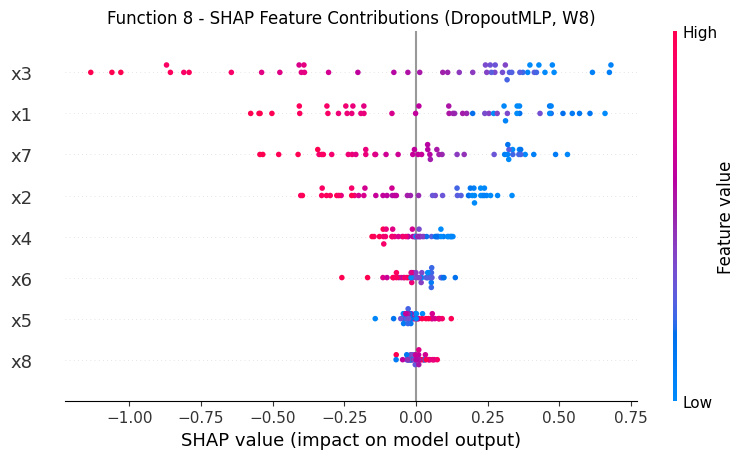


SHAP-derived importance (normalised):
  x1: 0.744
  x2: 0.450
  x3: 1.000
  x4: 0.154
  x5: 0.087
  x6: 0.124
  x7: 0.574
  x8: 0.061

Refinement anchor (W1): [0.182943 0.       0.       0.       0.999999 0.127124 0.092403 0.      ] -> 9.6724
Candidate pool: 35000 refinement + 15000 x3-sweep = 50000 total

mu   range: 7.672 to 9.678
sigma range: 0.137 to 0.460
kappa*sigma range: 0.240 to 0.804

Week 8 Query: 0.134058-0.010517-0.000000-0.000705-0.991616-0.110483-0.084702-0.012878
Source: Pool A (refinement)
MC mu: 9.5368, sigma: 0.3926
UCB:   10.2239


In [31]:
# =============================================================================
# FUNCTION 8 - 8D Black-Box
# changes:
#   - dropout increased from 0.2 to 0.25 — calibration ratio improved from 1.100 to 1.029 (less overfitting)
#   - adaptive kappa calculaton (kappa_base * calibration_ratio) to close the LOO feedback loop
#   - restructured candidate pool:
#      Pool A (35k): tight refinement around W1 (actual best)
#      Pool B (15k): structured x3 sweep to test non-monotonicity observed in SHAP plot, anchored to W1 values on other dims.
#     Dropped global LHS with 20k points in 8D is too sparse
# =============================================================================

print("\n" + "=" * 60)
print("Function 8 - Week 8")
print("=" * 60)

f8_inputs  = np.load('../Data/function_8/initial_inputs.npy')
f8_outputs = np.load('../Data/function_8/initial_outputs.npy')

prev_queries = np.array([
    [0.182943, 0.000000, 0.000000, 0.000000, 0.999999, 0.127124, 0.092403, 0.000000],  # W1: 9.672
    [0.022695, 0.000000, 0.274348, 0.000000, 0.999999, 0.127124, 0.028034, 0.000000],  # W2: 9.626
    [0.005086, 0.000000, 0.048567, 0.000000, 0.999999, 0.998962, 0.018674, 0.000000],  # W3: 9.546
    [0.000000, 0.000000, 0.012582, 0.000000, 0.999999, 0.000000, 0.066411, 0.000000],  # W4: 9.552
    [0.143046, 0.934478, 0.256793, 0.378273, 0.985471, 0.743394, 0.090143, 0.014829],  # W5: 9.146
    [0.060495, 0.027090, 0.006185, 0.132068, 0.160719, 0.354431, 0.001361, 0.931902],  # W6: 9.620
    [0.000000, 0.000000, 0.000000, 0.120009, 0.144817, 0.385066, 0.000000, 0.986589],  # W7: 9.583
])
prev_outputs = np.array([
    9.6723503773075, 9.6263579169495, 9.5463675507445,
    9.5519471979855, 9.1457303782294, 9.6199985919071,
    9.5831132283264,
])

all_inputs  = np.vstack([f8_inputs, prev_queries])
all_outputs = np.hstack([f8_outputs, prev_outputs])

print(f"Total points: {len(all_outputs)}, best: {all_outputs.max():.4f} (W1)")

# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs)
Y_sc = scaler_y.fit_transform(all_outputs.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

# MLP: hidden=24, dropout=0.25 (increased from 0.2 for better calibration)
class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

# LOO CV with dropout=0.25
loo_errors = []
loo_sigmas = []

for i in range(len(all_outputs)):
    X_train_loo = np.delete(all_inputs, i, axis=0)
    y_train_loo = np.delete(all_outputs, i)
    X_test_loo  = all_inputs[i:i+1]
    y_test_loo  = all_outputs[i]

    sx_loo = StandardScaler()
    sy_loo = StandardScaler()
    X_tr_sc_loo = sx_loo.fit_transform(X_train_loo)
    y_tr_sc_loo = sy_loo.fit_transform(y_train_loo.reshape(-1, 1)).ravel()
    X_te_sc_loo = sx_loo.transform(X_test_loo)

    X_tr_tensor = torch.tensor(X_tr_sc_loo, dtype=torch.float32)
    Y_tr_tensor = torch.tensor(y_tr_sc_loo, dtype=torch.float32).unsqueeze(1)
    X_te_tensor = torch.tensor(X_te_sc_loo, dtype=torch.float32)

    torch.manual_seed(42)
    model_loo     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
    optimiser_loo = torch.optim.Adam(model_loo.parameters(), lr=1e-3)

    model_loo.train()
    for epoch in range(1000):
        optimiser_loo.zero_grad()
        loss_loo = nn.MSELoss()(model_loo(X_tr_tensor), Y_tr_tensor)
        loss_loo.backward()
        optimiser_loo.step()

    mu_sc_loo, sigma_sc_loo = mc_predict(model_loo, X_te_tensor, n_passes=50)
    mu_loo    = sy_loo.inverse_transform(mu_sc_loo.reshape(-1, 1)).ravel()[0]
    sigma_loo = np.atleast_1d(sigma_sc_loo)[0] * sy_loo.scale_[0]

    loo_errors.append(abs(mu_loo - y_test_loo))
    loo_sigmas.append(sigma_loo)

loo_errors = np.array(loo_errors)
loo_sigmas = np.array(loo_sigmas)

# Adaptive kappa: base * calibration ratio (closing the LOO feedback loop)
kappa_base = 1.7
cal_ratio  = loo_errors.mean() / loo_sigmas.mean()
kappa      = kappa_base * cal_ratio

print(f"\nLOO Calibration (dropout=0.25):")
print(f"  mean |error|:        {loo_errors.mean():.4f}")
print(f"  std  |error|:        {loo_errors.std():.4f}")
print(f"  max  |error|:        {loo_errors.max():.4f}")
print(f"  mean sigma (LOO):    {loo_sigmas.mean():.4f}")
print(f"  ratio (error/sigma): {cal_ratio:.3f}  (1.0 = perfect calibration)")
print(f"  kappa (adaptive):    {kappa:.2f}")

# train final model
torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=24, dropout_rate=0.25)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

model.train()
for epoch in range(1000):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    loss.backward()
    optimiser.step()

print(f"Training loss (final): {loss.item():.4f}")

# --- SHAP on the DropoutMLP ---
model.eval()

def mlp_predict(X_np):
    """Wrapper for SHAP -- takes numpy array, returns numpy predictions."""
    X_t = torch.tensor(X_np, dtype=torch.float32)
    with torch.no_grad():
        preds = model(X_t).squeeze().numpy()
    return np.atleast_1d(preds)

background = X_sc[np.random.choice(len(X_sc), size=20, replace=False)]
explainer  = shap.KernelExplainer(mlp_predict, background)
shap_values = explainer.shap_values(X_sc, nsamples=100)

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_sc,
                  feature_names=[f'x{i+1}' for i in range(8)], show=False)
plt.title('Function 8 - SHAP Feature Contributions (DropoutMLP, W8)')
plt.tight_layout()
plt.show()

model.train()  # back to train mode for MC dropout

# --- SHAP importance for noise scaling ---
shap_importance = np.abs(shap_values).mean(axis=0)
shap_importance = shap_importance / shap_importance.max()

print("\nSHAP-derived importance (normalised):")
for i in range(8):
    print(f"  x{i+1}: {shap_importance[i]:.3f}")

# --- Candidate pool: Pool A (refinement) + Pool B (x3 sweep) ---
# W1 is the actual best point — anchor refinement there
w1_point = all_inputs[np.argmax(all_outputs)]
print(f"\nRefinement anchor (W1): {w1_point} -> {all_outputs.max():.4f}")

np.random.seed(42)

# Pool A: 35k points, tight perturbation around W1
# Active dims (x1, x3, x7): noise scale 0.05-0.08 based on SHAP
# Settled dims (x2, x4, x5, x6, x8): noise scale 0.01-0.02
pool_a_noise = np.random.randn(35000, 8)
for dim in range(8):
    if shap_importance[dim] > 0.5:  # active: x1, x3, x7
        pool_a_noise[:, dim] *= 0.05 + 0.03 * shap_importance[dim]
    else:  # settled: x2, x4, x5, x6, x8
        pool_a_noise[:, dim] *= 0.01 + 0.01 * shap_importance[dim]

pool_a = np.clip(w1_point + pool_a_noise, 0, 1)

# Pool B: 15k points, structured x3 sweep
# Fix x2=0, x4=0, x5=1, x8=0, x6~0.127 at W1 values
# Sweep x3 from 0 to 1, sample x1 and x7 with moderate noise around W1
pool_b = np.zeros((15000, 8))
pool_b[:, 2] = np.random.uniform(0, 1, 15000)          # x3: full sweep
pool_b[:, 0] = np.clip(w1_point[0] + np.random.randn(15000) * 0.15, 0, 1)  # x1: moderate noise
pool_b[:, 6] = np.clip(w1_point[6] + np.random.randn(15000) * 0.15, 0, 1)  # x7: moderate noise
pool_b[:, 1] = 0.0   # x2
pool_b[:, 3] = 0.0   # x4
pool_b[:, 4] = 1.0   # x5
pool_b[:, 5] = np.clip(w1_point[5] + np.random.randn(15000) * 0.02, 0, 1)  # x6: tight jitter
pool_b[:, 7] = 0.0   # x8

pool = np.vstack([pool_a, pool_b])
print(f"Candidate pool: {len(pool_a)} refinement + {len(pool_b)} x3-sweep = {len(pool)} total")

# scale and predict
pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=50)

mu    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma = sigma_sc * scaler_y.scale_[0]

# UCB with adaptive kappa
ucb      = mu + kappa * sigma
best_idx = np.argmax(ucb)
query    = pool[best_idx]

# report which pool the query came from
pool_source = "Pool A (refinement)" if best_idx < len(pool_a) else "Pool B (x3-sweep)"

print(f"\nmu   range: {mu.min():.3f} to {mu.max():.3f}")
print(f"sigma range: {sigma.min():.3f} to {sigma.max():.3f}")
print(f"kappa*sigma range: {(kappa*sigma).min():.3f} to {(kappa*sigma).max():.3f}")

print(f"\nWeek 8 Query: {format_query(query)}")
print(f"Source: {pool_source}")
print(f"MC mu: {mu[best_idx]:.4f}, sigma: {sigma[best_idx]:.4f}")
print(f"UCB:   {ucb[best_idx]:.4f}")